In [ ]:
import kagglehub

path = kagglehub.dataset_download("ayushv322/animal-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-classification' dataset.
Path to dataset files: /kaggle/input/animal-classification


In [ ]:
!cp -r /kaggle/input/animal-classification .

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import Input,Dense,GlobalAveragePooling2D,Lambda,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint,TensorBoard
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
class_names = ['Buffalo', 'Elephant', 'Rhino', 'Zebra']

In [ ]:
train=image_dataset_from_directory(
    directory="/content/animal-classification/Data",
    image_size=(224, 224),
    seed=42,
    validation_split=0.2,
    subset="training",
    class_names=class_names

)

Found 4000 files belonging to 4 classes.
Using 3200 files for training.


In [ ]:
val=image_dataset_from_directory(
    directory="/content/animal-classification/Data",
    image_size=(224, 224),
    seed=42,
    validation_split=0.2,
    subset="validation",
    class_names=class_names

)

Found 4000 files belonging to 4 classes.
Using 800 files for validation.


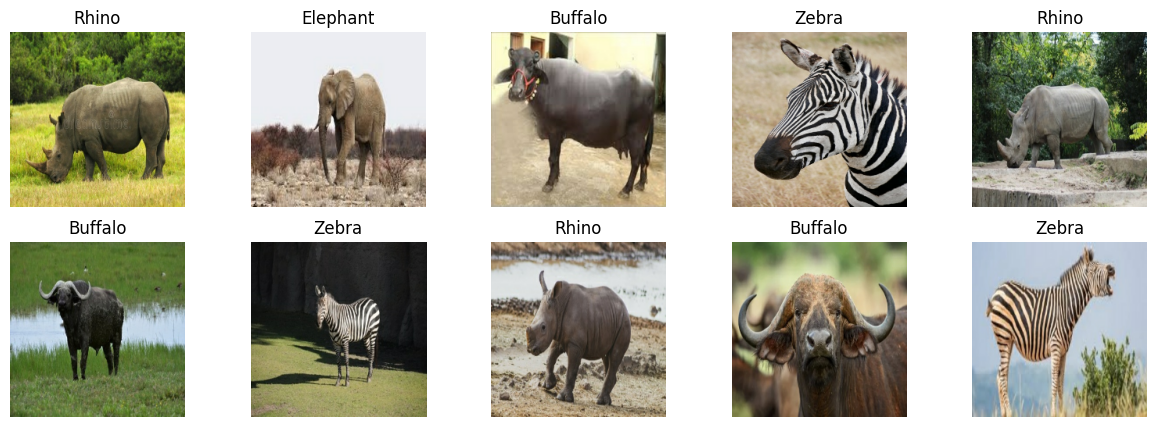

In [ ]:
i=0
n=10
plt.figure(figsize=(15, 5))
for img,label in train.take(n):
  i=i+1
  plt.subplot(2, 5, i)
  plt.imshow(img[i].numpy().astype("uint8"))
  plt.title(class_names[label[i].numpy()])
  plt.axis("off")


In [ ]:
x=Input(shape=(224,224,3))
x=Lambda(lambda x:tf.cast(x,'float32'))(x)
x=Lambda(lambda x:x/255)(x)


In [ ]:
vgg16=VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
    )
vgg16.trainable = False

In [ ]:
x=vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation="relu",kernel_initializer="he_normal")(x)
x=Dropout(0.3)(x)
x = Dense(64,activation="relu",kernel_initializer="he_normal")(x)
outputs = Dense(10,activation="softmax",kernel_initializer="glorot_uniform")(x)

In [ ]:
model=Model(inputs=vgg16.input,outputs=outputs)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    baseline=0.07
)

In [ ]:
lr_reduce=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
)

In [ ]:
checkpoint=ModelCheckpoint(
    filepath="model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
tensorBoard=TensorBoard(log_dir="logs")

In [ ]:
history=model.fit(train, epochs=50,validation_data=(val),callbacks=[tensorBoard,checkpoint,early_stop,lr_reduce])
history

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - accuracy: 0.2568 - loss: 8.5917 - val_accuracy: 0.7613 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 226ms/step - accuracy: 0.6590 - loss: 1.5081 - val_accuracy: 0.8712 - val_loss: 0.3634 - learning_rate: 1.0000e-04
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.7759 - loss: 0.8330 - val_accuracy: 0.9025 - val_loss: 0.2669 - learning_rate: 1.0000e-04
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.8226 - loss: 0.6260 - val_accuracy: 0.9250 - val_loss: 0.2206 - learning_rate: 1.0000e-04
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 220ms/step - accuracy: 0.8444 - loss: 0.5041 - val_accuracy: 0.9325 - val_loss: 0.1976 - learning_rate: 1.0000e-04
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.8742 - loss: 0.4611 - val_accuracy: 0.9375 - val_loss: 0.1937 - learning_rate: 1.0000e-04
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 20

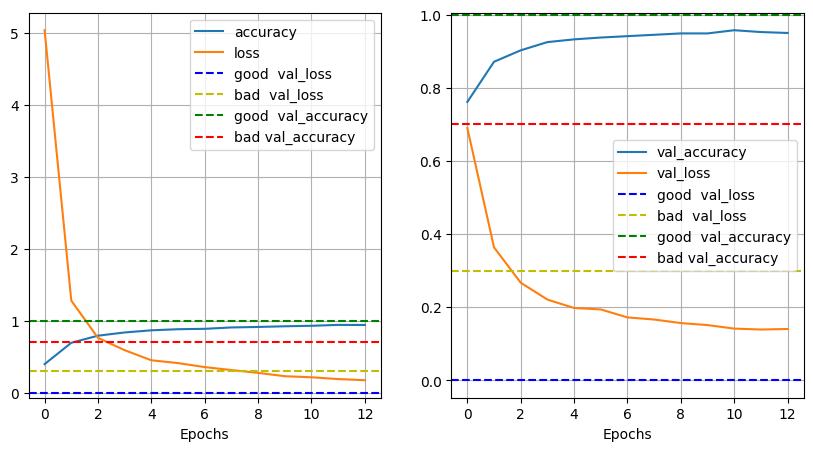

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'],label="accuracy")
plt.plot(history.history['loss'],label="loss")

plt.axhline(y=0, color='b', linestyle='--',label="good  val_loss")
plt.axhline(y=0.30, color='y', linestyle='--',label="bad  val_loss")

plt.axhline(y=1, color='g', linestyle='--',label="good  val_accuracy")
plt.axhline(y=0.70, color='r', linestyle='--',label="bad val_accuracy")

plt.xlabel("Epochs")
plt.grid()
plt.legend()



plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'],label="val_accuracy")
plt.plot(history.history['val_loss'],label="val_loss")

plt.axhline(y=0, color='b', linestyle='--',label="good  val_loss")
plt.axhline(y=0.30, color='y', linestyle='--',label="bad  val_loss")

plt.axhline(y=1, color='g', linestyle='--',label="good  val_accuracy")
plt.axhline(y=0.70, color='r', linestyle='--',label="bad val_accuracy")

plt.xlabel("Epochs")
plt.grid()
plt.legend()


plt.show()